In [1]:
# Load Data
import numpy as np

container = np.load('split_data.npz')

# Access data
X_train = container['X_train']
y_train = container['y_train']

# Access data
X_test = container['X_test']
y_test = container['y_test']

In [2]:
# Get best parameters for train data

from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score

result_list = []
for k in range(1,101):
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_train)
    
    score = r2_score(y_train, y_pred)

    params = {'k': k} 
    result = {'score': score, 'params': params}
    result_list.append(result)

best_result = max(result_list, key=lambda x: x['score'])

print(f"Max Score: {best_result['score']}")
print(f"Best Params: {best_result['params']}")

Max Score: 0.9098672246401044
Best Params: {'k': 8}


In [3]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score

model = KNeighborsRegressor(n_neighbors=8)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(r2_score(y_test, y_pred))

0.9036123689497036


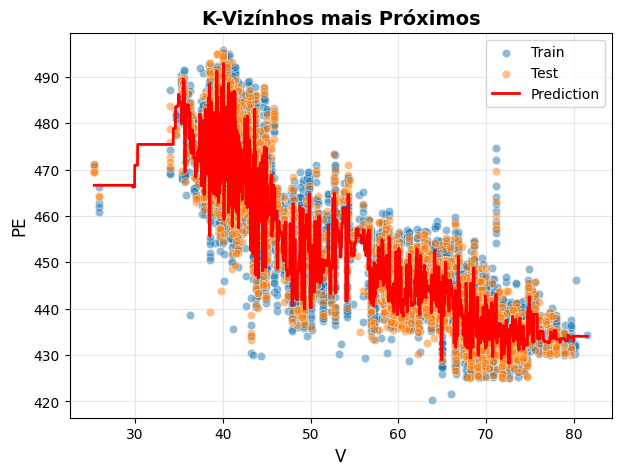

In [4]:
from utils import plot_predictions

step = 0.01
X_min = min(X_train.min(), X_test.min())
X_max = max(X_train.max(), X_test.max())
X_line = np.arange(X_min, X_max + step, step).reshape(-1, 1)
y_line = model.predict(X_line)

plot_predictions(X_line, y_line, X_train, y_train, X_test, y_test, title='K-Vizínhos mais Próximos', name='Images/knn.png')